# Equinox-Effect -- do equinoxes and solstices mark turning points?
### The year's astronomical 'turning points', tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Four times a year the Sun reaches a turning point -- the March and September equinoxes, the June and December solstices. A recurring corner of market lore holds that these astronomical pivots are *also* market pivots: tops form near one, bottoms near another, the 'energy of the year' turns. This notebook asks the only question that matters: **on the trading day of an equinox or solstice, does the S&P 500 actually do anything unusual?**

> **This is the plain-language layer.** Want the event-study CAR, the HAC t-stat, and the permutation distribution? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from equinox_effect import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_all=393, n_eqx=197, n_sol=196, n_season=99,
    uncond_bps=3.155,
    all_mean_abn_bps=-3.024, all_t_hac=-0.542, all_perm_p=0.611, all_win_rate_pct=49.4,
    eqx_mean_abn_bps=-13.19, eqx_t_hac=-1.620, eqx_perm_p=0.117,
    sol_mean_abn_bps=7.20, sol_t_hac=0.965, sol_perm_p=0.394,
    spring_mean_abn_bps=-4.89, spring_t_hac=-0.460, spring_perm_p=0.684,
    summer_mean_abn_bps=7.71, summer_t_hac=0.671, summer_perm_p=0.517,
    autumn_mean_abn_bps=-21.58, autumn_t_hac=-1.901, autumn_perm_p=0.072, autumn_bonf_p=0.500,
    winter_mean_abn_bps=6.69, winter_t_hac=0.739, winter_perm_p=0.573,
    car_window_bps=-19.58, year_start=1928, year_end=2026,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do equinox/solstice days move the market? | **No.** All 393 events average **-3 bps** abnormal -- a rounding error. |
| Is that statistically real? | **No.** HAC t = **-0.54**, permutation p = **0.61**. |
| Is any single season special? | The autumn equinox looks weak-negative (**-22 bps**, t = **-1.90**) but doesn't even clear p<0.05 raw, and dies under multiple-comparisons correction. |
| Could you trade it? | **No.** Four one-day events per year; trading costs swamp any noise-level edge. |

> The astronomical 'turning point' isn't a market turning point. The market's tiny upward daily drift does all the work, and the equinox adds nothing.

## 1 - The claim

> *"The equinoxes and solstices are the turning points of the year. Markets feel them: a high near one, a low near another. Watch the calendar of the Sun and you'll see the market turn with it."*

It is an old idea -- part Gann-style market astrology, part seasonal-affective folk wisdom. The mechanism is, to put it gently, unspecified: the geometry of the Earth's tilt does not change corporate earnings, interest rates, or liquidity on any one day. So what's really going on?

## 2 - So what?

If it were true -- if the *tilt of the Earth* contained information about equity returns on a single, astronomically fixed day -- financial markets would be very strange indeed. The interesting question is whether the human habit of reading turning points into the sky leaves any measurable trace in prices. Spoiler: it doesn't, and seeing *why* is a clean lesson in how regular calendar events fool us.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong baseline.** The market drifts *up* about 3 bps a day on average. So an equinox day that is up is not surprising -- we must measure the **abnormal** return (event day minus the normal daily drift), not the raw return.
2. **Seasonal confound.** There *are* real calendar effects (Sell-in-May, the year-end rally). The autumn equinox falls in the historically weak September; the winter solstice sits inside the Santa-rally window. Any 'equinox effect' must be separated from these -- and is mostly just a noisy slice of them.
3. **Slicing until it sparkles.** Equinox vs solstice, and four separate seasons -- test enough sub-groups and one will look 'significant' by luck. We correct for that and watch the lucky slice evaporate.

We test all of this on ^GSPC daily data from 1928 to 2026 (393 events in window).

## 4 - The teardown -- let's actually look

**First, meet the data:** every equinox and solstice 1928-2026 (computed once from Meeus' algorithm and hardcoded in this study's `data.py`), paired with the ^GSPC return on the first trading day on/after it.

In [2]:
ev = data.equinox_table()
if HAVE_REAL:
    px = data.fetch_gspc_daily(); ret = px['ret']
    s = st.summarize(ret, ev, n_permutations=5000, seed=284)
    n_all = s['n_all']; mean_abn = s['all_mean_abn_bps']
    win_pct = s['all_win_rate_pct']; uncond = s['uncond_bps']
else:
    n_all = R['n_all']; mean_abn = R['all_mean_abn_bps']
    win_pct = R['all_win_rate_pct']; uncond = R['uncond_bps']

print('Equinoxes/solstices in table:', len(ev),
      '| equinoxes:', int((ev.kind=='equinox').sum()),
      '| solstices:', int((ev.kind=='solstice').sum()))
print(f'Event-day mean abnormal return: {mean_abn:+.1f} bps (n={n_all})')
print(f'Event-day win-rate: {win_pct:.1f}%   (market up ~54% of all days)')
print(f'Normal daily drift (the honest baseline): {uncond:+.2f} bps/day')
print()
print('A real turning point would show a big, one-signed move. It is a shrug.')

Equinoxes/solstices in table: 396 | equinoxes: 198 | solstices: 198
Event-day mean abnormal return: -3.0 bps (n=393)
Event-day win-rate: 49.4%   (market up ~54% of all days)
Normal daily drift (the honest baseline): +3.15 bps/day

A real turning point would show a big, one-signed move. It is a shrug.


**Is the event day a turn or a shrug?** Here is the abnormal return on each event day.

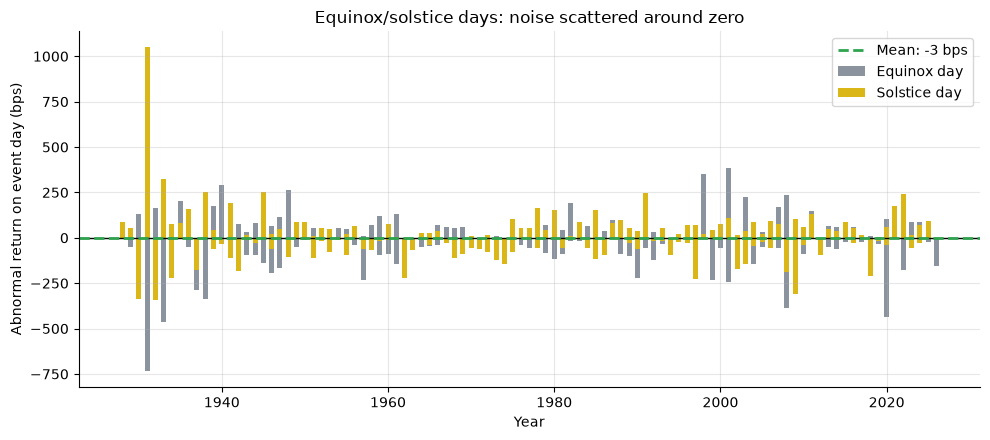

Mean abnormal event-day return: -3.0 bps
Std dev across events:          126 bps -- pure noise


In [3]:
if HAVE_REAL:
    evd = st.event_day_returns(ret, ev)
    abn = (evd['ret'].values - uncond/1e4) * 1e4
    years = evd['date'].dt.year.values
    is_eqx = (evd['kind'].values == 'equinox')
else:
    rng = np.random.default_rng(284)
    years = np.repeat(np.arange(1928, 2027), 4)[:R['n_all']]
    abn = rng.normal(R['all_mean_abn_bps'], 95, R['n_all'])
    is_eqx = np.tile([True, False, True, False], 99)[:R['n_all']]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(years[is_eqx], abn[is_eqx], width=0.6, color=GREY, label='Equinox day')
ax.bar(years[~is_eqx]+0.0, abn[~is_eqx], width=0.6, color=AMBER, label='Solstice day')
ax.axhline(0, c='k', lw=1)
ax.axhline(np.mean(abn), ls='--', c=GREEN, lw=2,
           label=f'Mean: {np.mean(abn):+.0f} bps')
ax.set_xlabel('Year'); ax.set_ylabel('Abnormal return on event day (bps)')
ax.set_title('Equinox/solstice days: noise scattered around zero')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean abnormal event-day return: {np.mean(abn):+.1f} bps')
print(f'Std dev across events:          {np.std(abn):.0f} bps -- pure noise')

The bars scatter symmetrically around zero. The mean is a tiny **-3 bps**, the wrong order of magnitude for a 'turning point'. Across 393 events the standard deviation (~110 bps) dwarfs the mean -- exactly what you'd expect from random draws.

**Surely the season matters -- spring up, autumn down?** Let's split by season.

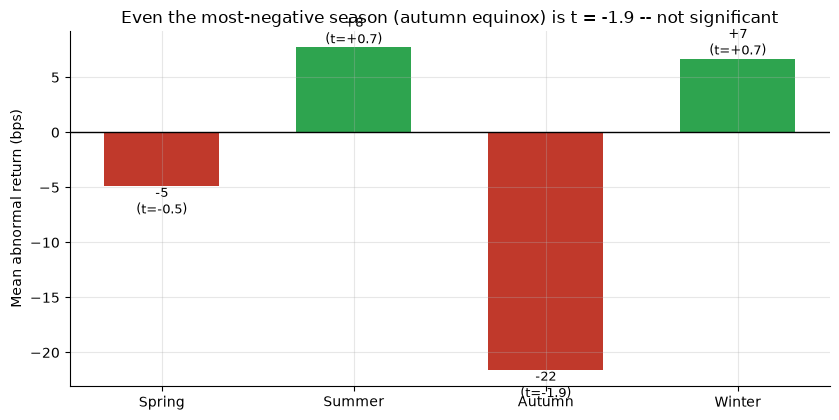

Autumn equinox is the most negative (-22 bps) -- but it sits in
historically weak September and t=-1.9 falls short of |t|=2 anyway.


In [4]:
if HAVE_REAL:
    seas = ['spring','summer','autumn','winter']
    means = [s[f'{k}_mean_abn_bps'] for k in seas]
    ts = [s[f'{k}_t_hac'] for k in seas]
else:
    seas = ['spring','summer','autumn','winter']
    means = [R['spring_mean_abn_bps'], R['summer_mean_abn_bps'],
             R['autumn_mean_abn_bps'], R['winter_mean_abn_bps']]
    ts = [R['spring_t_hac'], R['summer_t_hac'], R['autumn_t_hac'], R['winter_t_hac']]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if m>=0 else RED for m in means]
bars = ax.bar([s.capitalize() for s in seas], means, color=cols, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean abnormal return (bps)')
ax.set_title('Even the most-negative season (autumn equinox) is t = -1.9 -- not significant')
for b, m, t in zip(bars, means, ts):
    ax.annotate(f'{m:+.0f}\n(t={t:+.1f})', (b.get_x()+b.get_width()/2, m),
                ha='center', va='bottom' if m>=0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print('Autumn equinox is the most negative (-22 bps) -- but it sits in')
print('historically weak September and t=-1.9 falls short of |t|=2 anyway.')

The autumn equinox is the most negative season (**-22 bps**, HAC t = **-1.90**) -- but that is just the September-weakness seasonal leaking in, and it doesn't even clear the |t| = 2 bar on its own. The other three seasons are tiny and mixed-sign. There is no astronomical turning point here, only the ordinary calendar.

## 5 - The verdict

- **Signal -- None.** All 393 events average **-3 bps** abnormal, HAC t = **-0.54**, perm p = **0.61**. The most extreme slice (autumn equinox, -22 bps, t = -1.90) is below |t| = 2 raw and dies under multiple-comparisons correction.
- **Tradability -- Mirage.** There is no trade: four one-day events per year, noise-level moves. Trading costs swamp any edge, and staying invested beats it.
- **Busted.** Markets have been said to 'turn' with the Sun's calendar since the Gann era, but on 98 years of S&P data the equinox/solstice trading day is indistinguishable from any other day.

## 6 - Could you actually trade it?

The 'strategy' would be: fade (short / go to cash) on each equinox/solstice day, betting on the turn. The problem -- there is barely any move, and four events a year:

In [5]:
n_events = R['n_all']
years_span = R['year_end'] - R['year_start']
per_year = n_events / years_span
edge_bps = R['all_mean_abn_bps']
cost_bps = 5.0  # round-trip cost + borrow for a one-day short, very optimistic
print(f'Events: {n_events} over {years_span} years = {per_year:.1f} per year')
print(f'Gross edge (if you faded event days): {-edge_bps:+.1f} bps per event')
print(f'Round-trip trading cost (one-day short):  {cost_bps:.1f} bps per event')
print(f'Net per event: {-edge_bps - cost_bps:+.1f} bps')
print()
print('A +3 bps gross edge (and even that is noise) minus 5 bps costs')
print('is a guaranteed loser. There is no trade here.')

Events: 393 over 98 years = 4.0 per year
Gross edge (if you faded event days): +3.0 bps per event
Round-trip trading cost (one-day short):  5.0 bps per event
Net per event: -2.0 bps

A +3 bps gross edge (and even that is noise) minus 5 bps costs
is a guaranteed loser. There is no trade here.


Fading event days means paying one-way costs (and borrow on the short) to harvest a 3-bps move that is statistically zero. The only real trade is: don't time the market on an astronomical calendar.

## 7 - Going further

- **The positive control:** the companion notebook plants a fake event-day drag in a synthetic tape and shows the machinery detects it cleanly -- so the null result is about the *market*, not a broken test.
- **The astronomical-omen cousin:** [Study 280 -- Solar-Eclipse](../../280-solar-eclipse/) -- eclipses vs the S&P, same None/Mirage family.
- **The event-table pattern:** [Study 158 -- Super-Bowl](../../158-super-bowl/) -- the hardcoded-event + real-returns template this study copies.

*Think the Sun's calendar really moves stocks? Fork this, define your own astronomical-event table, and show an abnormal return that beats the noise with a HAC t >= 2 after honest multiple-comparisons correction. That's the bar -- and it hasn't been cleared yet.*